# Train DeepONet on Fluent cell-center subdomains

This notebook uses the non-grid dataset. The trunk queries are original Fluent cell centers inside each subdomain, not a 256×256 raster grid. Branch sensors are exterior BC points plus interpolated interface points.

In [47]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

MODULE_DIR = Path.cwd()

if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from deeponet_fluent_dataset import (
    build_fluent_deeponet_dataset,
    DeepONetCellDataset,
)

from fluent_deeponet import (
    FeatureNormalizer,
    DeepONet,
    train_deeponet_one_epoch,
    evaluate_deeponet,
    predict_deeponet_cell_sample,
)

from eval_fluent_deeponet import (
    InterfaceIterationConfig,
    iterative_unknown_interface_inference,
    select_sample_indices_by_ar,
    make_plot_dict_from_iterative_result,
)

from plot import (
    plot_prediction_imshow_from_points,
    predict_cell_sample,
    local_query_to_physical,
    select_samples_by_ar,
    collect_predictions_for_data,
)

torch.manual_seed(0)
np.random.seed(0)
rng = np.random.default_rng()
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda:2


## Case file paths

In [2]:
ROOT_DIR = Path("/home/hantianl/Documents/PIDIF/runs_2d/rect_ar")

available_ars = list(range(1, 51))

case_files = {
    i: {
        "mesh": ROOT_DIR / f"rect_ar{i:02d}_1e-1mps_2c/rect_ar{i:02d}.msh.h5",
        "dat": ROOT_DIR / f"rect_ar{i:02d}_1e-1mps_2c/case2d.dat.h5",
    }
    for i in available_ars
}

# Quick path check for the ARs used below.
for ar in [10, 20, 30, 50]:
    print(ar, case_files[ar]["mesh"].exists(), case_files[ar]["dat"].exists())

10 True True
20 True True
30 True True
50 True True


## Build non-grid training/validation dataset

In [3]:
ARS = list(range(10, 31))
VALID_ARS = [20, 25, 30]
TRAIN_ARS = [ar for ar in ARS if ar not in VALID_ARS]

N_SUBDOMAINS_TRAIN = TRAIN_ARS
N_SUBDOMAINS_VALID = VALID_ARS
N_INTERFACE_POINTS = 256
N_WALL_POINTS = 256
INTERFACE_PLACEMENT = "fixed"
INTERFACE_JITTER = 0.0
MIN_SUBDOMAIN_WIDTH = 0.01

bc_kwargs = {
    "inlet_u": 0.1,
    "inlet_v": 0.0,
    "inlet_T": 273.0,
    "outlet_p": 0.0,
    "top_T": 273.0,
    "bottom_T": 275.0,
    "wall_u": 0.0,
    "wall_v": 0.0,
}

train_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    ar_list=TRAIN_ARS,
    n_subdomains=N_SUBDOMAINS_TRAIN,
    n_interface_points=N_INTERFACE_POINTS,
    n_wall_points=N_WALL_POINTS,
    interface_placement=INTERFACE_PLACEMENT,
    interface_jitter=INTERFACE_JITTER,
    min_subdomain_width=MIN_SUBDOMAIN_WIDTH,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)

valid_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    ar_list=VALID_ARS,
    n_subdomains=N_SUBDOMAINS_VALID,
    n_interface_points=N_INTERFACE_POINTS,
    n_wall_points=N_WALL_POINTS,
    interface_placement="fixed",
    interface_jitter=0,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)

samples = train_data["samples"]
metadata = train_data["metadata"]
branch_channel_names = list(train_data["branch_channel_names"])
trunk_channel_names = list(train_data["trunk_channel_names"])
output_channel_names = list(train_data["output_channel_names"])

ars = np.asarray([int(round(m["aspect_ratio"])) for m in metadata], dtype=np.int64)
subdomain_ids = np.asarray([int(m["subdomain_id"]) for m in metadata], dtype=np.int64)
local_aspect_ratios = np.asarray([float(m["local_aspect_ratio"]) for m in metadata], dtype=np.float32)
n_cells = np.asarray([int(m["n_cells"]) for m in metadata], dtype=np.int64)

print("Train samples:", len(train_data["samples"]))
print("Valid samples:", len(valid_data["samples"]))

print("Train branch channels:", train_data["branch_channel_names"])
print("Train trunk channels:", train_data["trunk_channel_names"])
print("Output channels:", train_data["output_channel_names"])

print("Example train sample:")
print("branch:", train_data["samples"][0]["branch"].shape)
print("query:", train_data["samples"][0]["query"].shape)
print("target:", train_data["samples"][0]["target"].shape)

Processing AR=10 realization=0


Processing AR=11 realization=0
Processing AR=12 realization=0
Processing AR=13 realization=0
Processing AR=14 realization=0
Processing AR=15 realization=0
Processing AR=16 realization=0
Processing AR=17 realization=0
Processing AR=18 realization=0
Processing AR=19 realization=0
Processing AR=21 realization=0
Processing AR=22 realization=0
Processing AR=23 realization=0
Processing AR=24 realization=0
Processing AR=26 realization=0
Processing AR=27 realization=0
Processing AR=28 realization=0
Processing AR=29 realization=0
Processing AR=20 realization=0
Processing AR=25 realization=0
Processing AR=30 realization=0
Train samples: 345
Valid samples: 75
Train branch channels: ['x_local', 'y_local', 'wall_mask', 'interface_mask', 'boundary_pressure', 'boundary_temperature', 'boundary_u', 'boundary_v', 'known_pressure', 'known_temperature', 'known_u', 'known_v', 'local_aspect_ratio']
Train trunk channels: ['x_local', 'y_local']
Output channels: ['pressure', 'temperature', 'u', 'v']
Example tr

In [4]:
train_metadata = train_data["metadata"]
valid_metadata = valid_data["metadata"]

train_ars_array = np.asarray(
    [m["aspect_ratio"] for m in train_metadata],
    dtype=np.float32,
)

valid_ars_array = np.asarray(
    [m["aspect_ratio"] for m in valid_metadata],
    dtype=np.float32,
)

train_subdomain_ids = np.asarray(
    [m["subdomain_id"] for m in train_metadata],
    dtype=np.int64,
)

valid_subdomain_ids = np.asarray(
    [m["subdomain_id"] for m in valid_metadata],
    dtype=np.int64,
)

print("Train ARs:", sorted(set(train_ars_array.astype(int).tolist())))
print("Valid ARs:", sorted(set(valid_ars_array.astype(int).tolist())))

Train ARs: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 26, 27, 28, 29]
Valid ARs: [20, 25, 30]


In [5]:
def concatenate_targets(data):
    return np.concatenate(
        [sample["target"] for sample in data["samples"]],
        axis=0,
    ).astype(np.float32)


train_targets_all = concatenate_targets(train_data)

y_normalizer = FeatureNormalizer(train_targets_all)

print("Y mean:", y_normalizer.mean)
print("Y std:", y_normalizer.std)

train_local_aspects = np.asarray(
    [m["local_aspect_ratio"] for m in train_data["metadata"]],
    dtype=np.float32,
)

local_aspect_mean = float(train_local_aspects.mean())
local_aspect_std = float(train_local_aspects.std() + 1.0e-6)

print("local_aspect_mean:", local_aspect_mean)
print("local_aspect_std:", local_aspect_std)

Y mean: tensor([ 2.3686e-03,  2.7328e+02,  1.0007e-01, -1.0800e-07])
Y std: tensor([0.0017, 0.5126, 0.0354, 0.0006])
local_aspect_mean: 1.0
local_aspect_std: 9.999999974752427e-07


## DataLoaders

In [6]:
N_QUERY_TRAIN = 8192
N_QUERY_VALID = 8192

BATCH_SIZE = 20

train_ds = DeepONetCellDataset(
    samples=train_data["samples"],
    sample_indices=None,
    n_query_points=N_QUERY_TRAIN,
    random_query=True,
    target_y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=train_data["branch_channel_names"],
)

valid_ds = DeepONetCellDataset(
    samples=valid_data["samples"],
    sample_indices=None,
    n_query_points=N_QUERY_VALID,
    random_query=False,
    target_y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=valid_data["branch_channel_names"],
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

branch_batch, query_batch, target_batch, sample_idx_batch = next(iter(train_loader))

print("branch batch:", branch_batch.shape)
print("query batch:", query_batch.shape)
print("target batch:", target_batch.shape)
print("sample indices:", sample_idx_batch)

branch batch: torch.Size([20, 1024, 13])
query batch: torch.Size([20, 8192, 2])
target batch: torch.Size([20, 8192, 4])
sample indices: tensor([141,  84, 255,  53, 332, 166, 312, 290,  67,  37,  31, 201, 212, 280,
        257,  18, 223, 275, 287, 295])


## Model

In [7]:
branch_input_dim = train_data["samples"][0]["branch"].shape[-1]
trunk_input_dim = train_data["samples"][0]["query"].shape[-1]
output_channels = train_data["samples"][0]["target"].shape[-1]

model = DeepONet(
    branch_input_dim=branch_input_dim,
    trunk_input_dim=trunk_input_dim,
    output_channels=output_channels,
    latent_dim=128,
    branch_point_hidden_dim=128,
    branch_point_depth=3,
    branch_global_hidden_dim=128,
    branch_global_depth=3,
    trunk_hidden_dim=128,
    trunk_depth=4,
    aggregation="mean",
    activation="gelu",
    layer_norm=False,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1.0e-3, weight_decay=1.0e-4)
EPOCHS = 1000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(model.config())

{'branch_input_dim': 13, 'trunk_input_dim': 2, 'output_channels': 4, 'latent_dim': 128, 'branch_point_hidden_dim': 128, 'branch_point_depth': 3, 'branch_global_hidden_dim': 128, 'branch_global_depth': 3, 'trunk_hidden_dim': 128, 'trunk_depth': 4, 'aggregation': 'mean', 'activation': 'gelu', 'layer_norm': False}


## Train

In [8]:
checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = checkpoint_dir / "deeponet_cell_rect_ar10_30.pt"

LOSS_TYPE = "mse"
LAMBDA_BC = 0  # set to 0.0 to train only on sampled cell-center targets

best_valid_rel = float("inf")
history = []
y_normalizer = y_normalizer.to(DEVICE)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_deeponet_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=DEVICE,
        loss_type=LOSS_TYPE,
        lambda_bc=LAMBDA_BC,
        branch_channel_names=branch_channel_names,
    )
    scheduler.step()

    valid_metrics = evaluate_deeponet(
        model=model,
        loader=valid_loader,
        device=DEVICE,
        y_normalizer=y_normalizer,
    )
    valid_rel = valid_metrics["relative_l2"]
    valid_channel_rel = valid_metrics["channel_relative_l2"]

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_mse": valid_metrics["mse"],
        "valid_relative_l2": valid_rel,
        "valid_channel_relative_l2": valid_channel_rel,
    })

    if valid_rel < best_valid_rel:
        best_valid_rel = valid_rel
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "model_config": model.config(),
                "y_normalizer": y_normalizer.state_dict(),
                "branch_channel_names": train_data["branch_channel_names"],
                "trunk_channel_names": train_data["trunk_channel_names"],
                "output_channel_names": train_data["output_channel_names"],
                "train_ars": TRAIN_ARS,
                "valid_ars": VALID_ARS,
                "n_subdomains_train": N_SUBDOMAINS_TRAIN,
                "n_subdomains_valid": N_SUBDOMAINS_VALID,
                "n_interface_points": N_INTERFACE_POINTS,
                "n_wall_points": N_WALL_POINTS,
                "interface_placement": INTERFACE_PLACEMENT,
                "interface_jitter": INTERFACE_JITTER,
                "min_subdomain_width": MIN_SUBDOMAIN_WIDTH,
                "local_aspect_mean": local_aspect_mean,
                "local_aspect_std": local_aspect_std,
                "bc_kwargs": bc_kwargs,
            },
            checkpoint_path,
        )

    if epoch == 1 or epoch % 10 == 0:
        channel_msg = ", ".join(f"{name}={err:.3e}" for name, err in zip(output_channel_names, valid_channel_rel))
        print(
            f"Epoch {epoch:04d} | train loss={train_loss:.3e} | "
            f"valid MSE={valid_metrics['mse']:.3e} | valid rel L2={valid_rel:.3e} | {channel_msg}"
        )

print("Best validation relative L2:", best_valid_rel)
print("Saved:", checkpoint_path)

Epoch 0001 | train loss=9.214e-01 | valid MSE=3.034e-02 | valid rel L2=1.273e-03 | pressure=5.396e-01, temperature=1.268e-03, u=3.413e-01, v=9.229e-01
Epoch 0010 | train loss=1.616e-01 | valid MSE=3.960e-03 | valid rel L2=4.281e-04 | pressure=1.265e-01, temperature=4.586e-04, u=1.076e-01, v=5.870e-01
Epoch 0020 | train loss=7.462e-02 | valid MSE=1.541e-03 | valid rel L2=2.626e-04 | pressure=4.088e-02, temperature=2.855e-04, u=8.141e-02, v=4.182e-01
Epoch 0030 | train loss=4.797e-02 | valid MSE=6.656e-04 | valid rel L2=1.766e-04 | pressure=3.306e-02, temperature=1.880e-04, u=4.314e-02, v=3.877e-01
Epoch 0040 | train loss=4.925e-02 | valid MSE=4.537e-04 | valid rel L2=1.473e-04 | pressure=4.412e-02, temperature=1.551e-04, u=4.021e-02, v=3.953e-01
Epoch 0050 | train loss=3.148e-02 | valid MSE=5.781e-04 | valid rel L2=1.708e-04 | pressure=4.542e-02, temperature=1.755e-04, u=3.361e-02, v=3.319e-01
Epoch 0060 | train loss=2.994e-02 | valid MSE=8.680e-04 | valid rel L2=2.037e-04 | pressure=1.

## Load best checkpoint

In [9]:
ckpt = torch.load(checkpoint_path, map_location=DEVICE)

best_model = DeepONet(**ckpt["model_config"]).to(DEVICE)
best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()

y_normalizer = FeatureNormalizer.from_state_dict(ckpt["y_normalizer"]).to(DEVICE)
local_aspect_mean = float(ckpt["local_aspect_mean"])
local_aspect_std = float(ckpt["local_aspect_std"])

print("Loaded:", checkpoint_path)

Loaded: checkpoints/deeponet_cell_rect_ar10_30.pt


/tmp/ipykernel_1349934/1104796799.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=DEVICE)


## Predict one validation subdomain at original cell centers

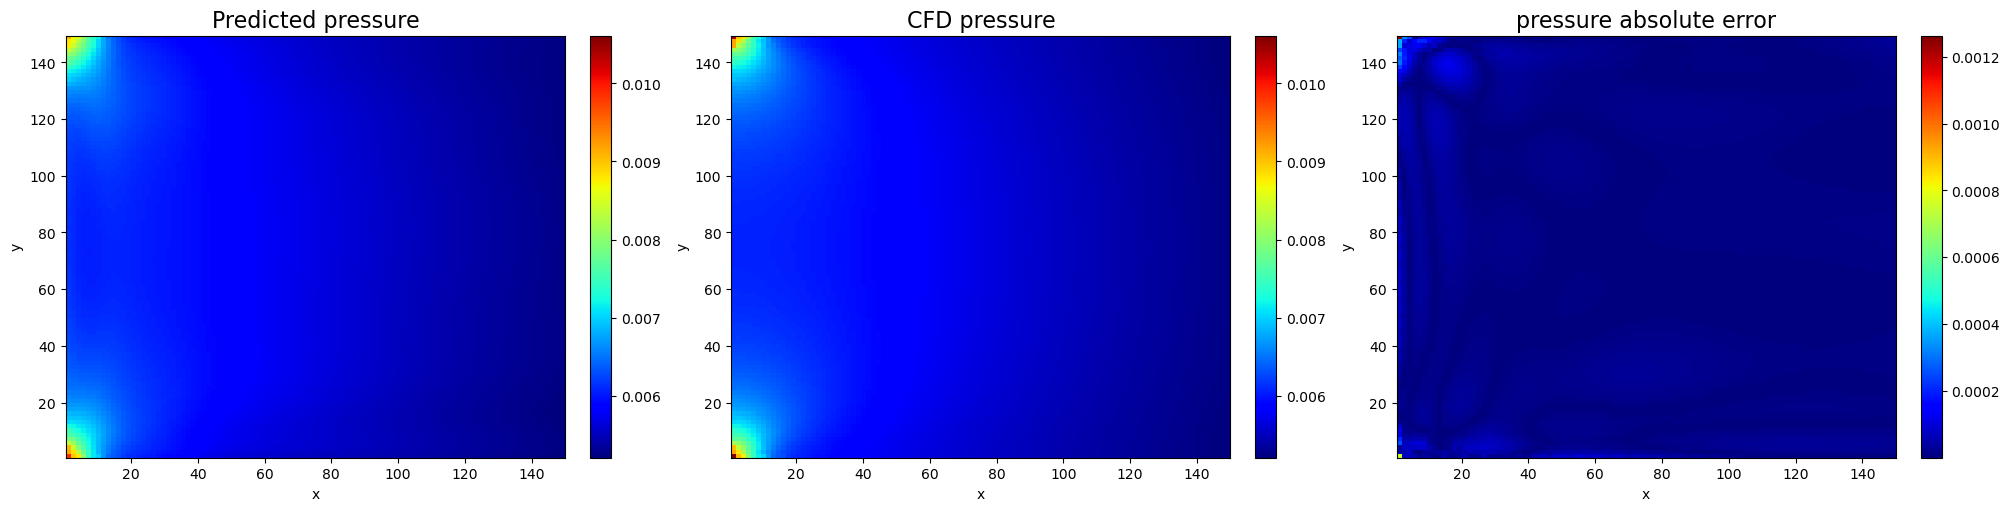

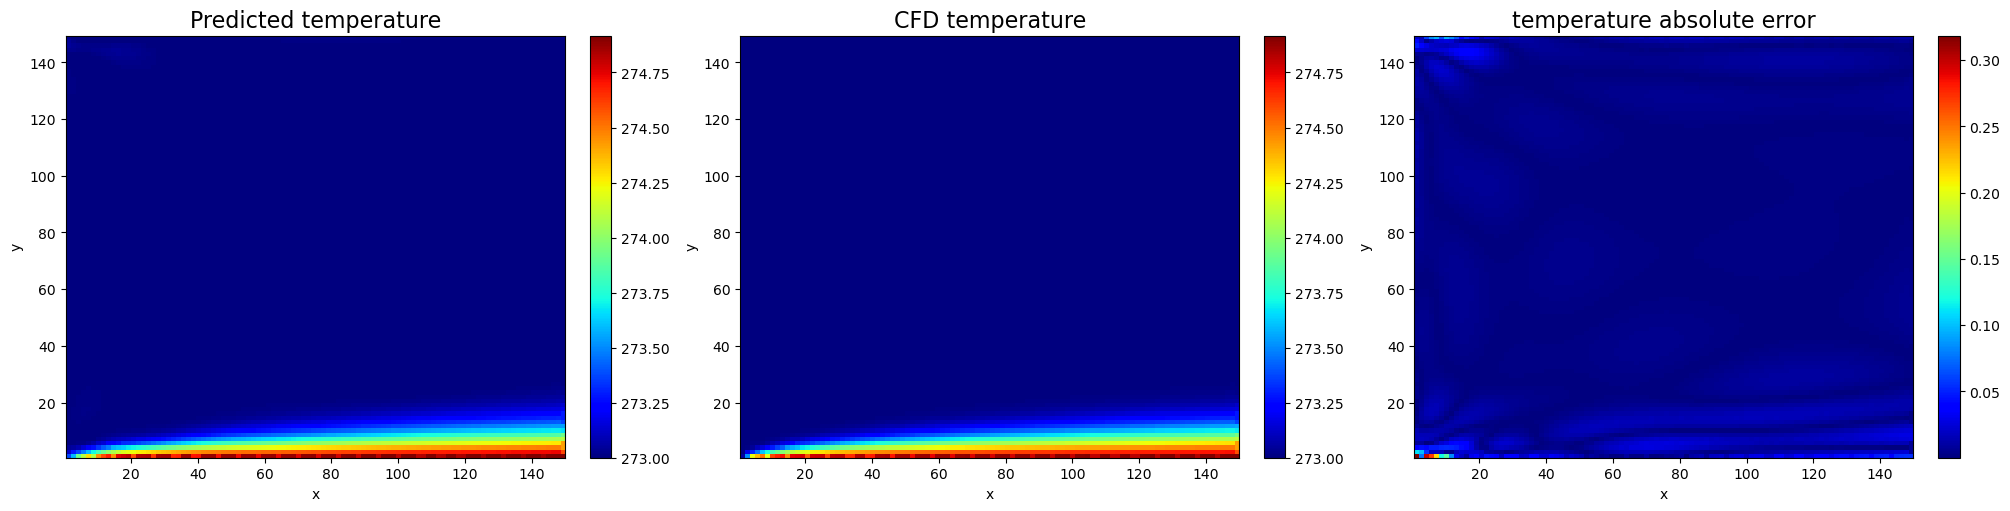

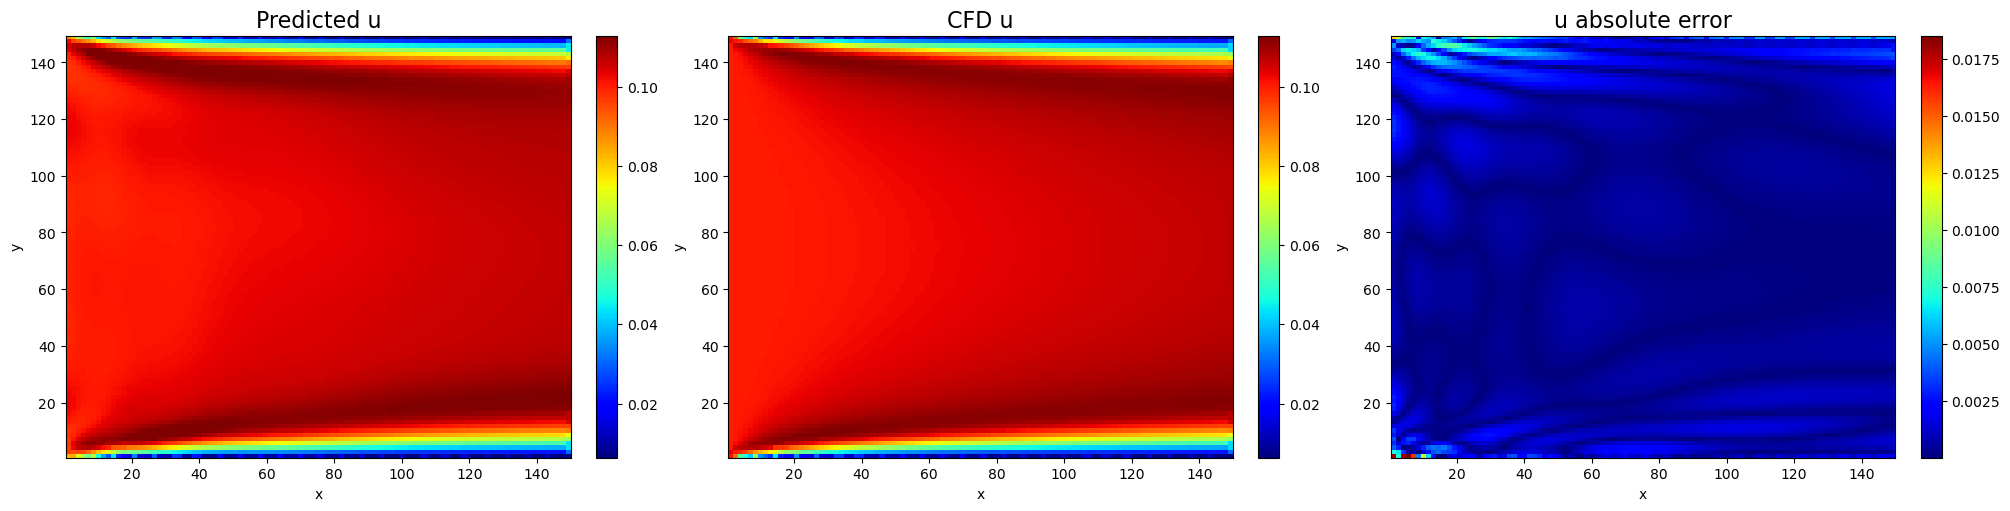

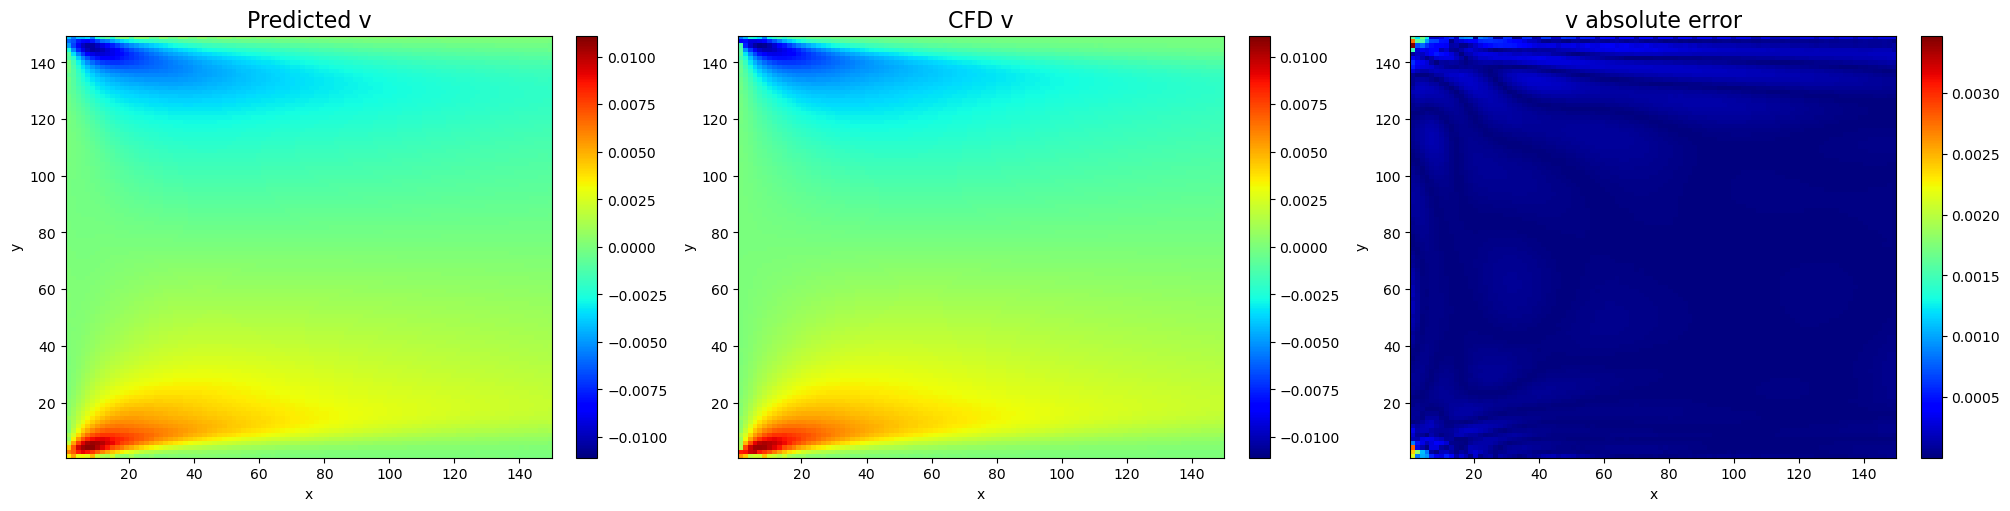

Total plotted points: 260696
x range: 0.5096231 2999.474
y range: 0.51863676 149.47418


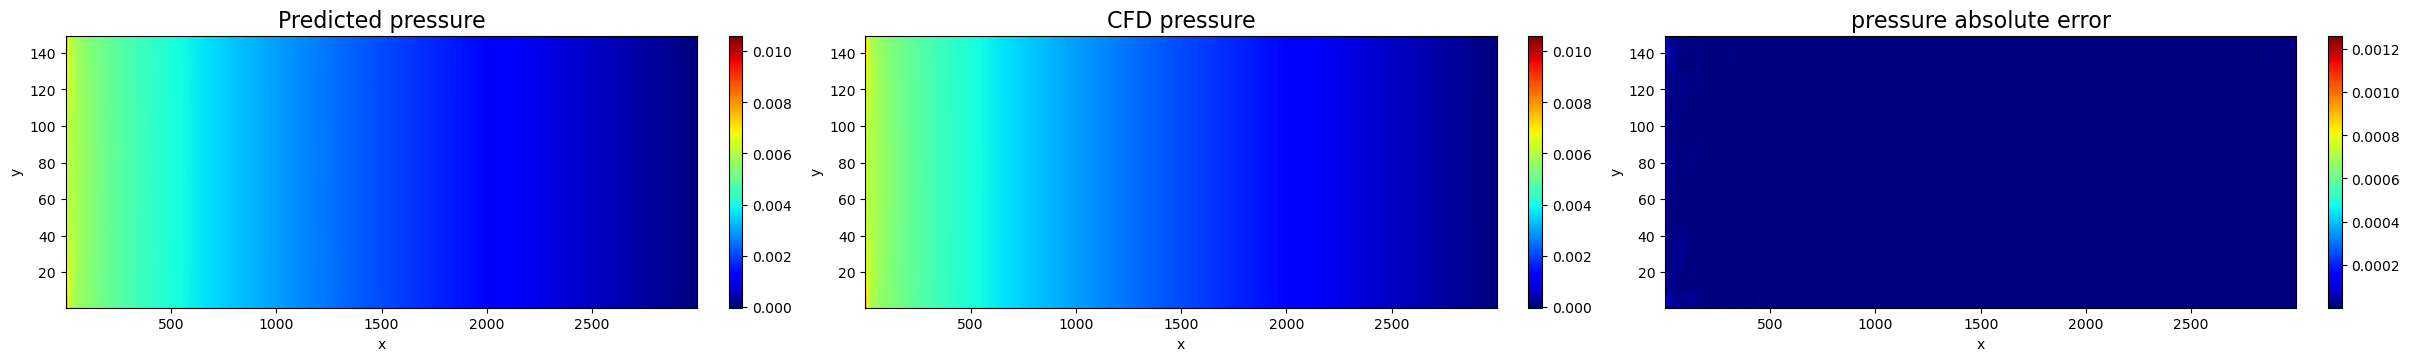

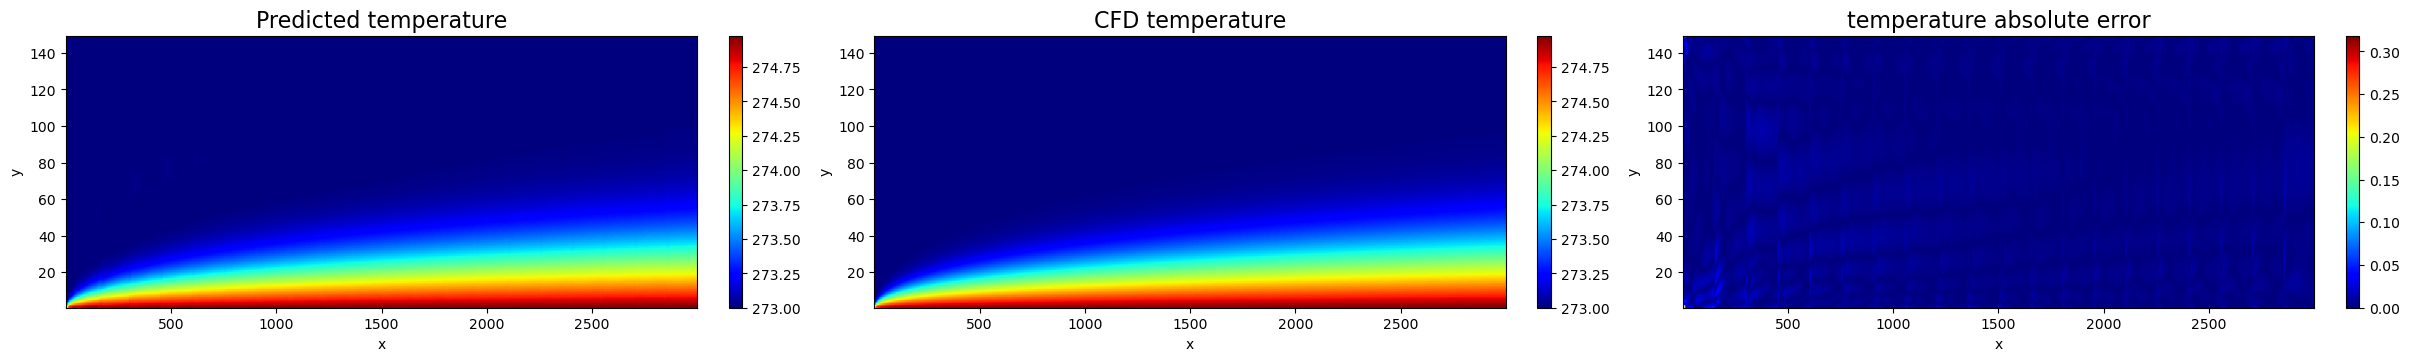

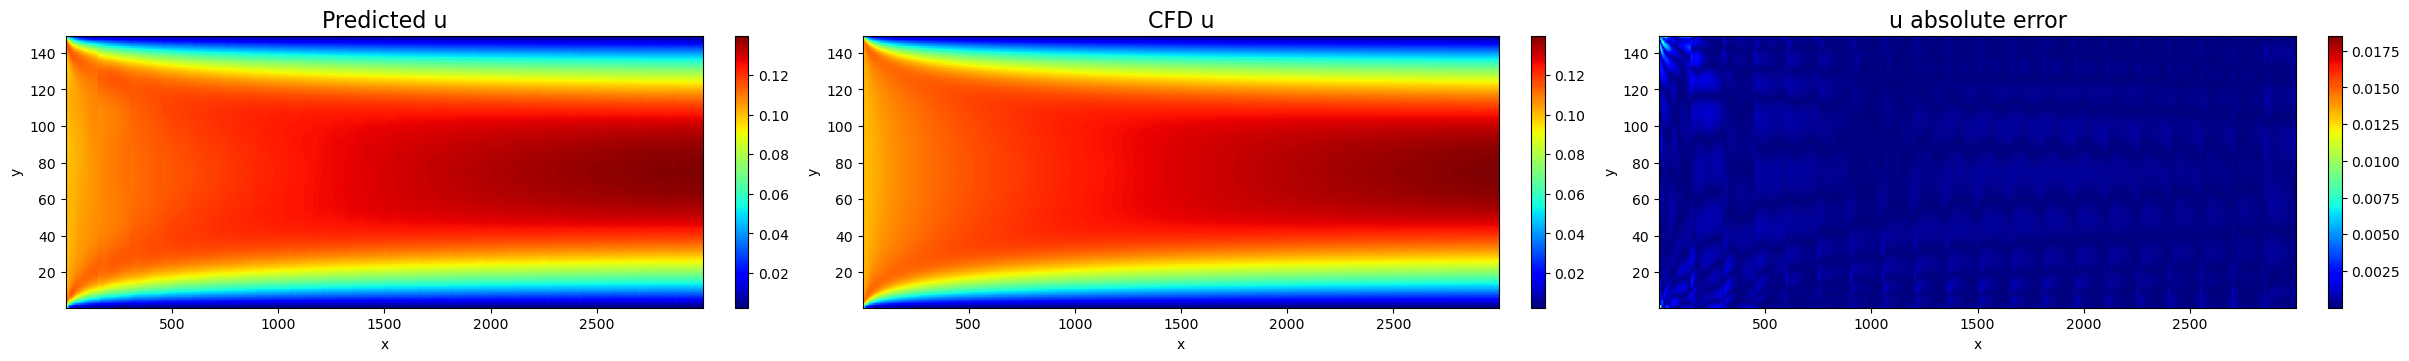

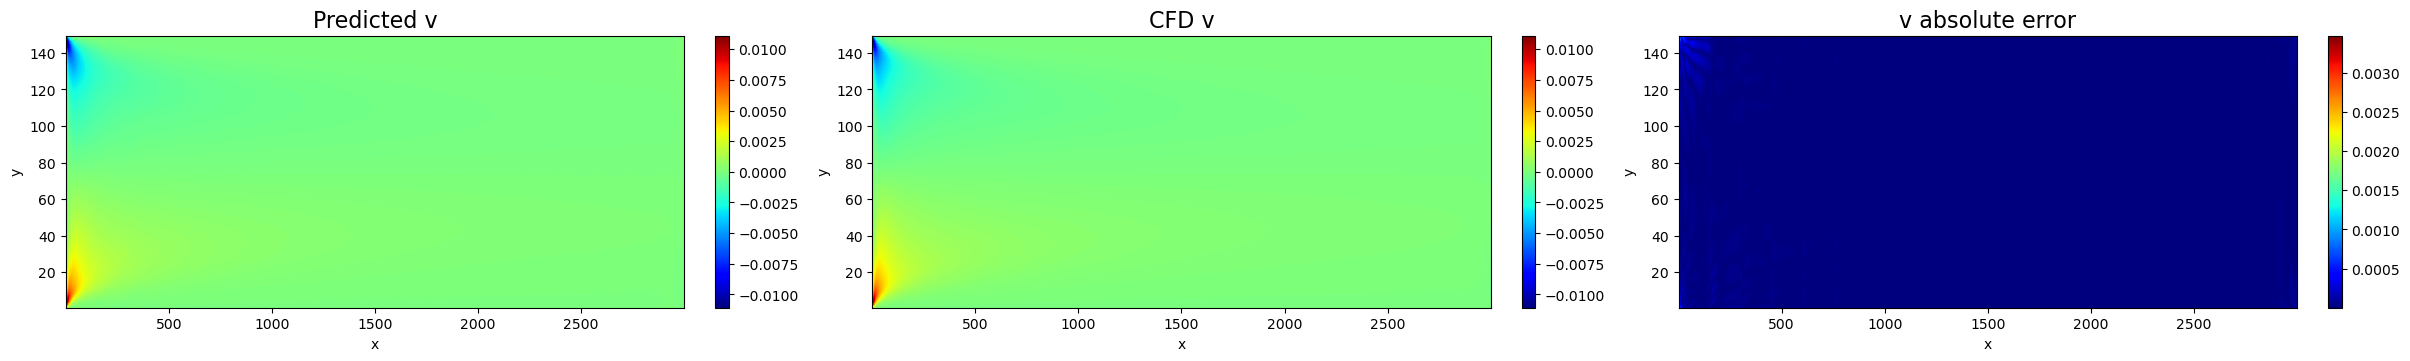

In [30]:
valid_sample_id = 0

sample = valid_data["samples"][valid_sample_id]
metadata = valid_data["metadata"][valid_sample_id]
output_channel_names = list(valid_data["output_channel_names"])

query_local, pred_phys, truth_phys = predict_cell_sample(
    model=model,
    sample=sample,
    device=DEVICE,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=valid_data["branch_channel_names"],
)

x_phys, y_phys = local_query_to_physical(query_local, metadata)

for field_idx, field_name in enumerate(output_channel_names):
    plot_prediction_imshow_from_points(
        x=x_phys,
        y=y_phys,
        pred=pred_phys,
        truth=truth_phys,
        field_name=field_name,
        field_idx=field_idx,
        figsize=(20, 5),
        n_y_plot=100,
        output_dir=None,
        filename_prefix=f"valid_sample_{valid_sample_id}",
    )
    
AR_TO_PLOT = int(VALID_ARS[0])

valid_ar_sample_ids = select_samples_by_ar(valid_data, AR_TO_PLOT)

plot_data = collect_predictions_for_data(
    model=model,
    data=valid_data,
    device=DEVICE,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    sample_indices=valid_ar_sample_ids,
)

print("Total plotted points:", plot_data["x"].shape[0])
print("x range:", plot_data["x"].min(), plot_data["x"].max())
print("y range:", plot_data["y"].min(), plot_data["y"].max())

for field_name in output_channel_names:
    field_idx = output_channel_names.index(field_name)

    plot_prediction_imshow_from_points(
        x=plot_data["x"],
        y=plot_data["y"],
        pred=plot_data["pred"],
        truth=plot_data["truth"],
        field_name=field_name,
        field_idx=field_idx,
        n_x_plot=100 * AR_TO_PLOT,
        n_y_plot=100,
        output_dir=None,
        filename_prefix=f"valid_AR{AR_TO_PLOT}",
    )

## Optional: AR=50 iterative unknown-interface test

Processing AR=50 realization=0


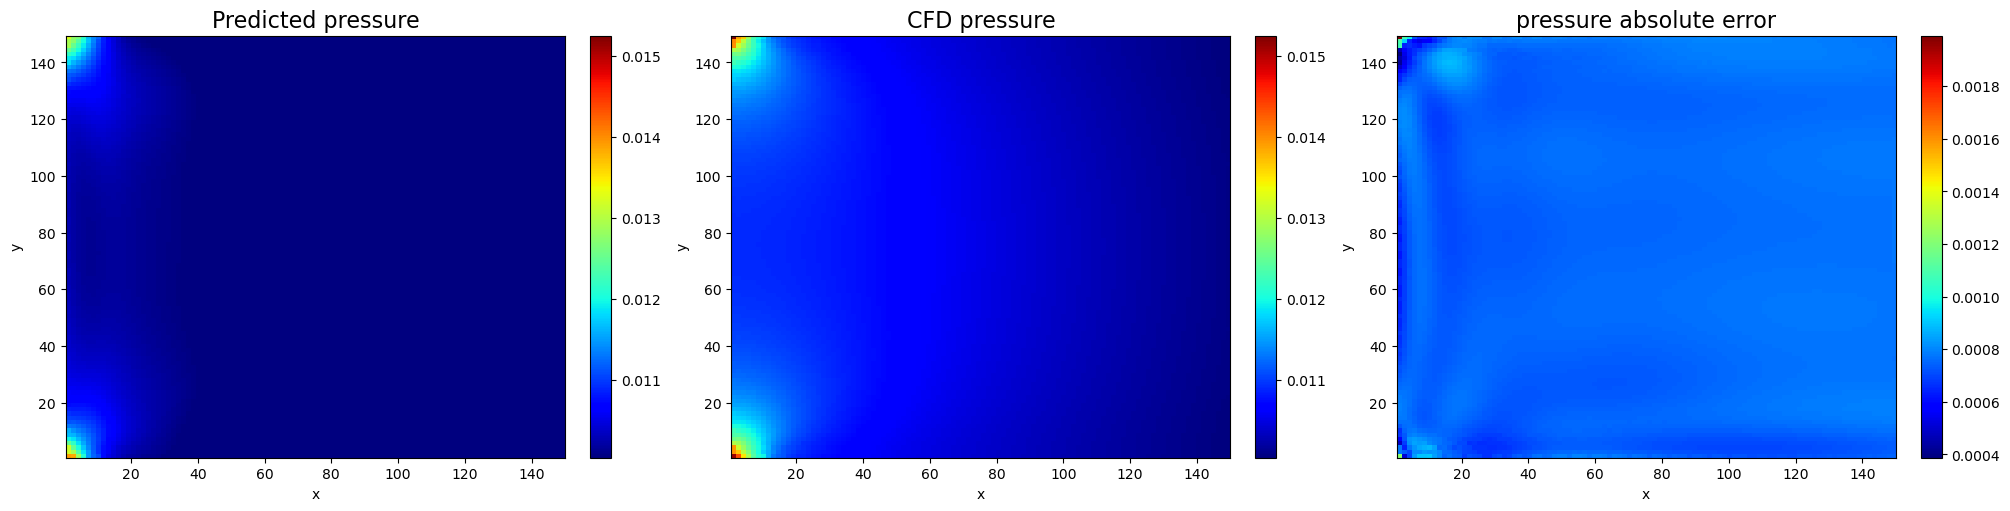

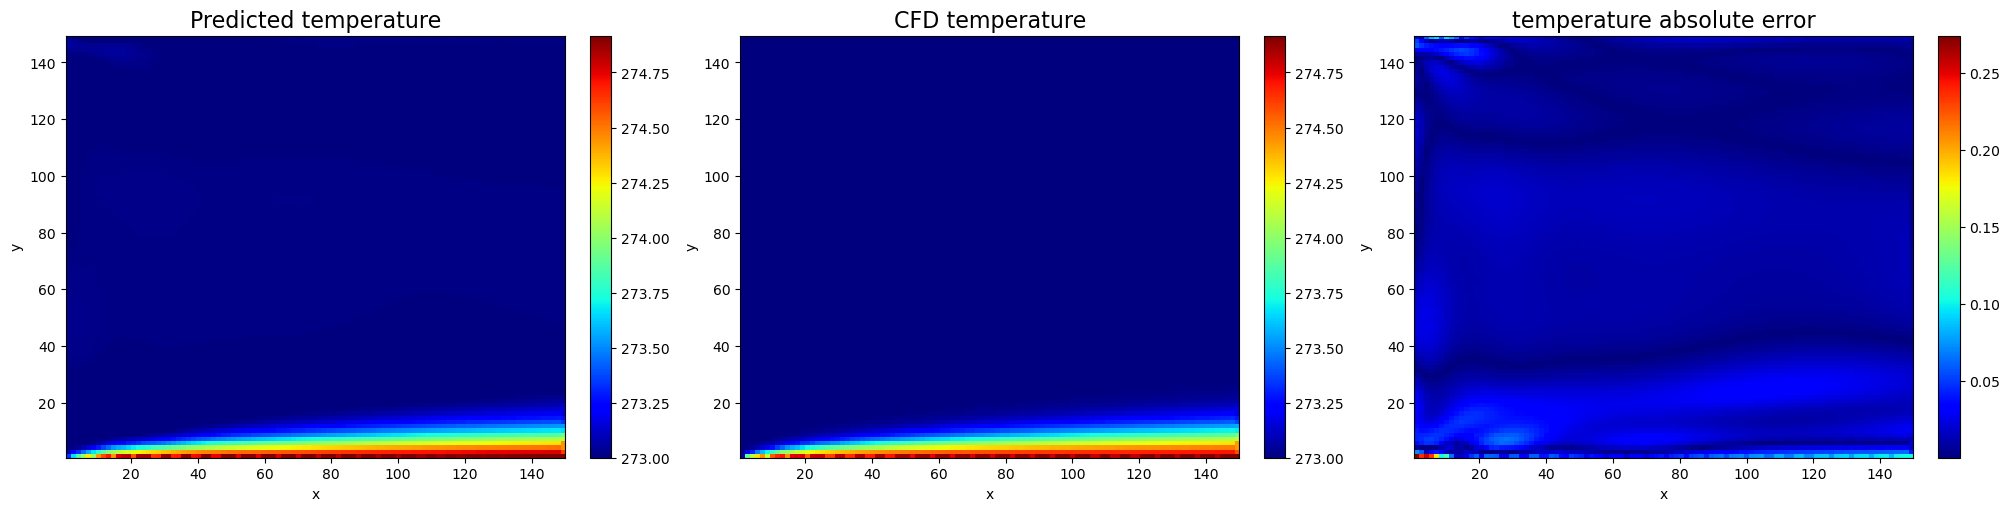

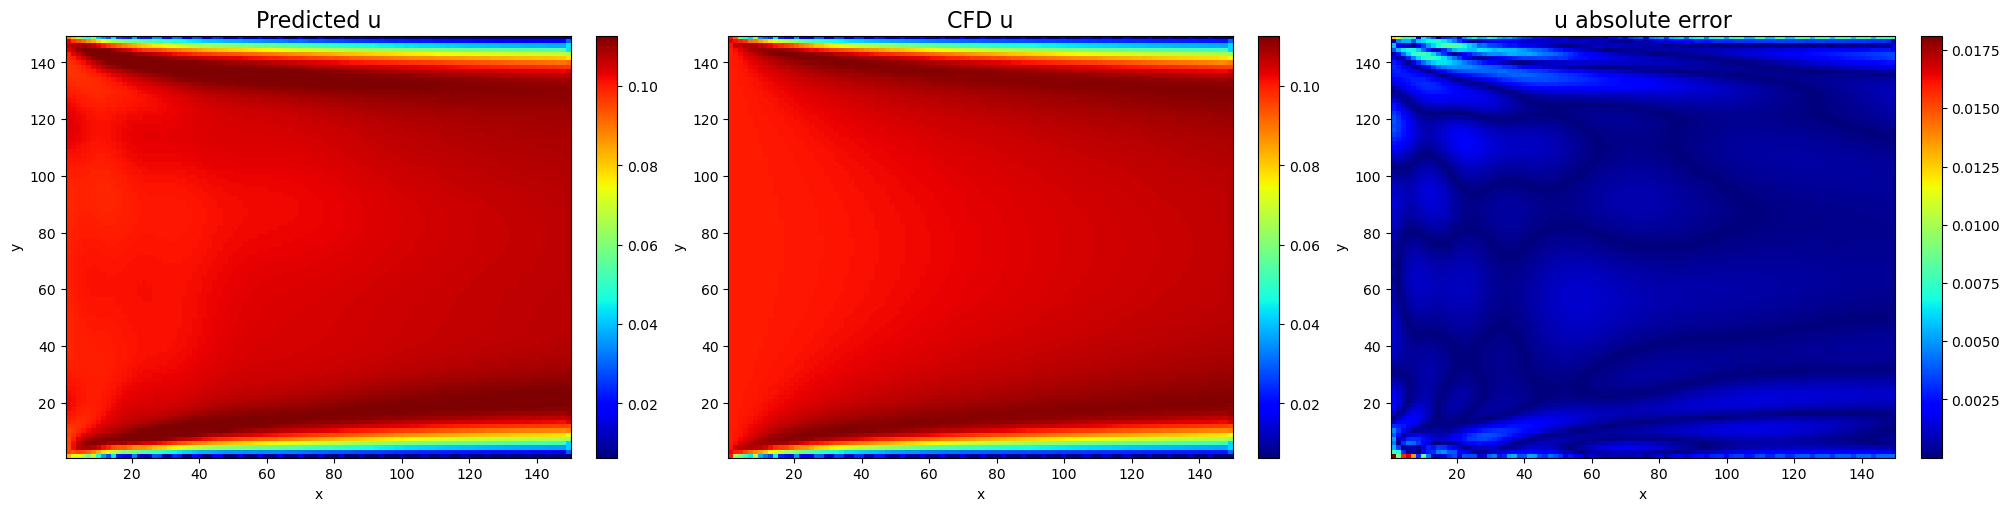

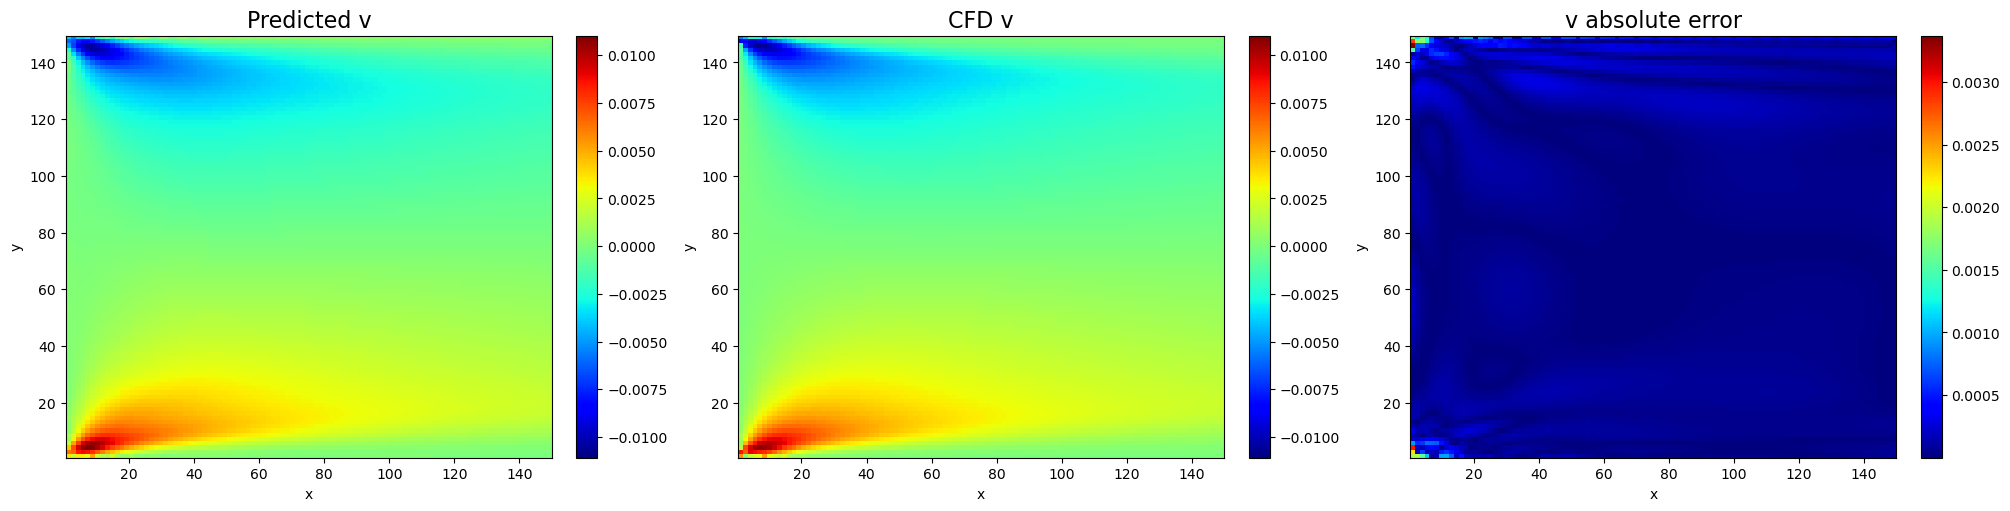

Total plotted points: 651482
x range: 0.5120154 7499.4707
y range: 0.5280181 149.4933


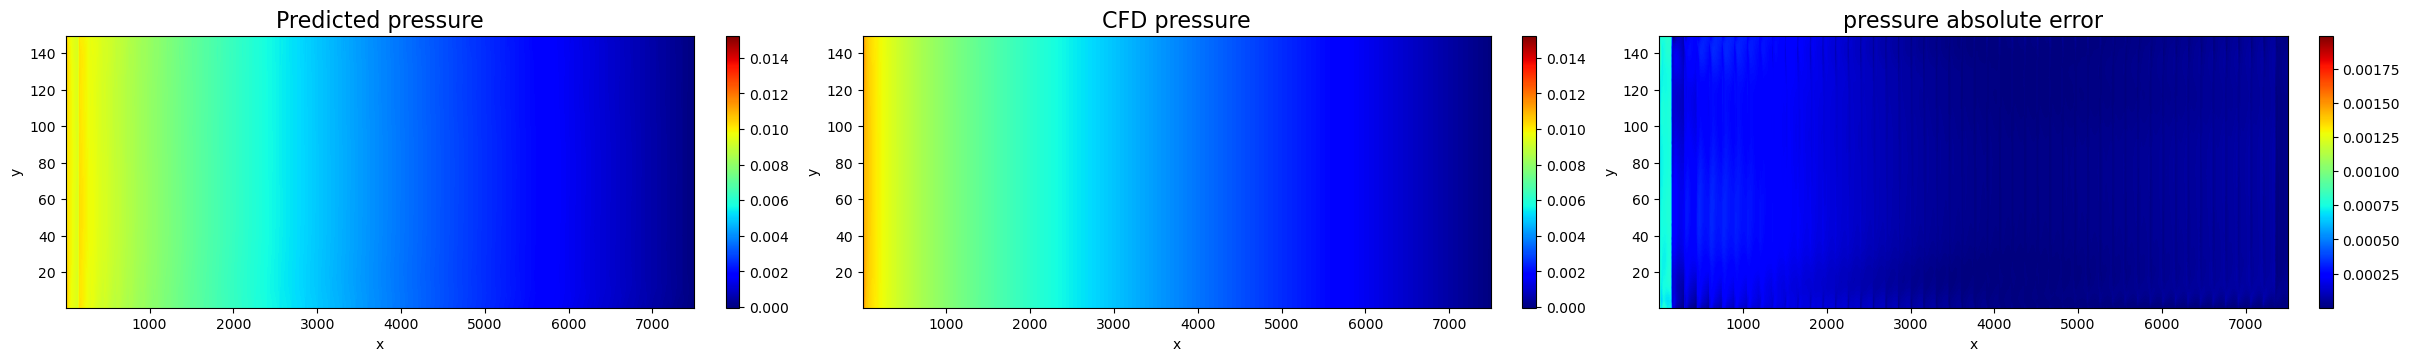

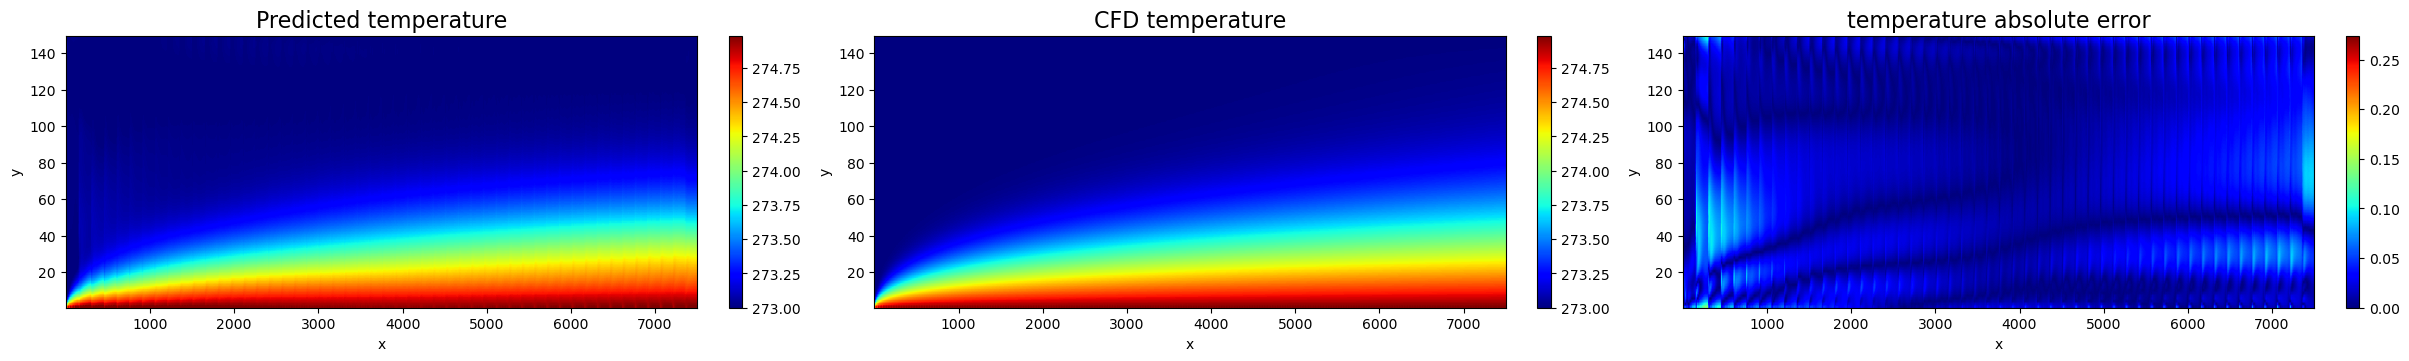

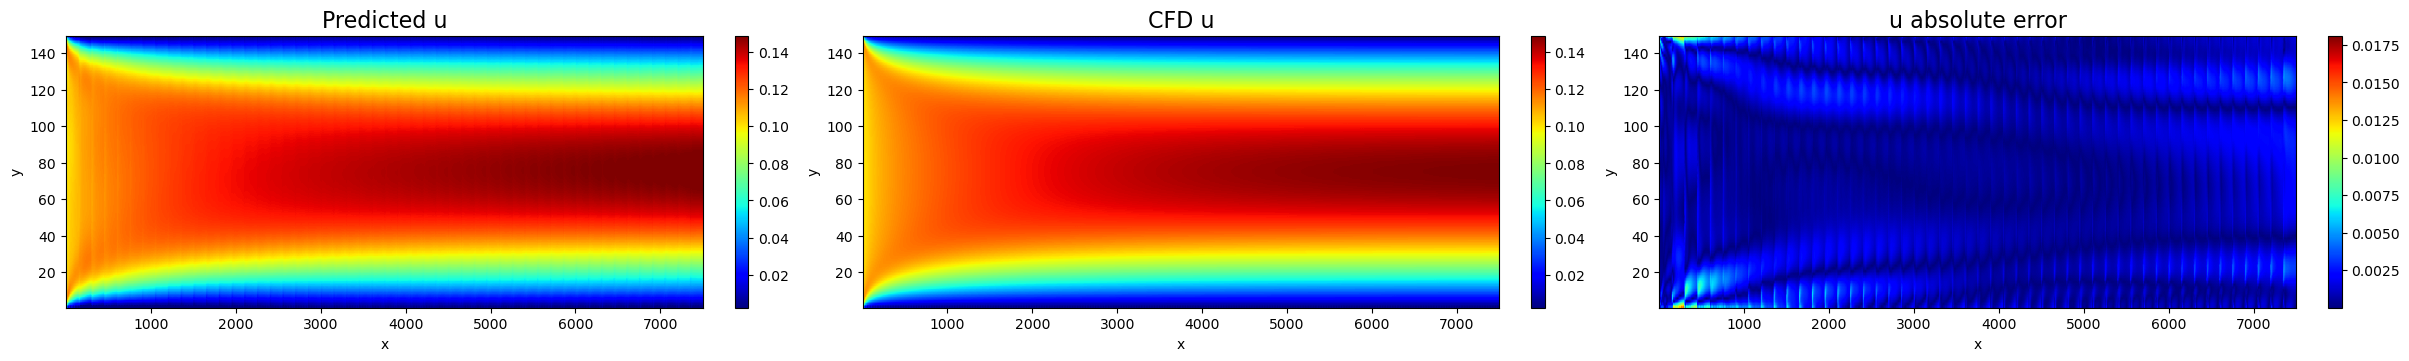

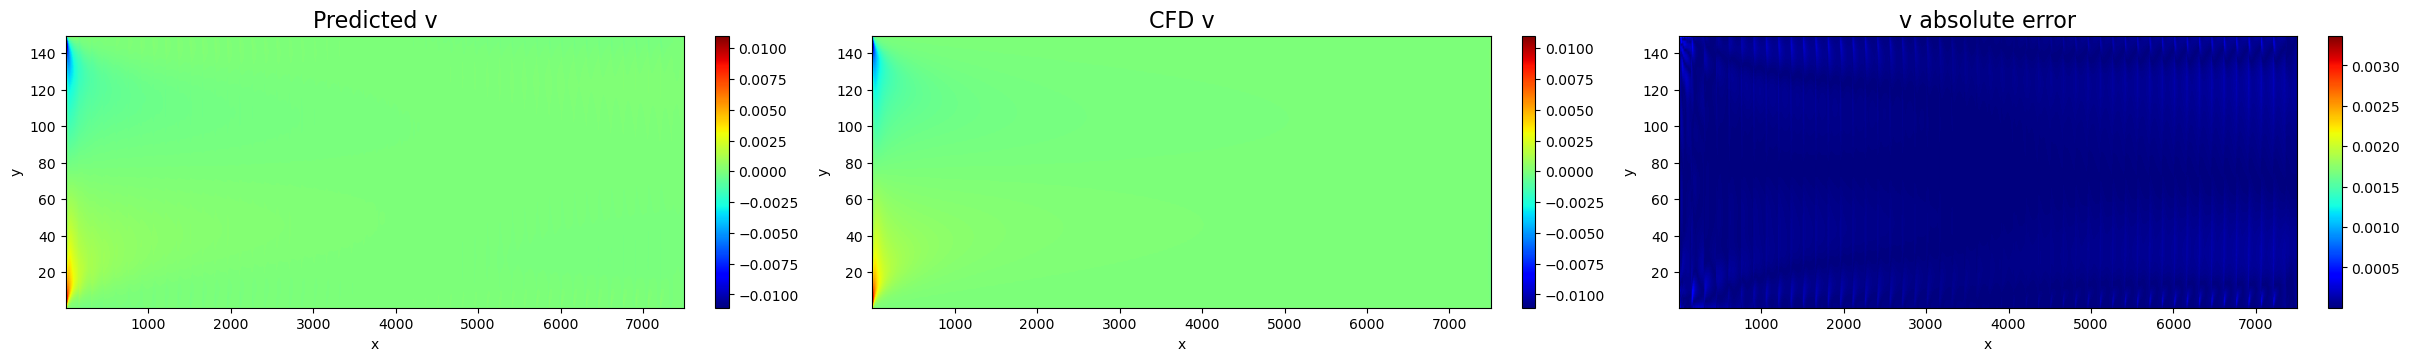

In [ ]:
test_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    ar_list=[50],
    n_subdomains=50,
    n_interface_points=N_INTERFACE_POINTS,
    n_wall_points=N_WALL_POINTS,
    interface_placement="fixed",
    interface_jitter=0,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)
test_sample_id = 0

sample = test_data["samples"][test_sample_id]
metadata = test_data["metadata"][test_sample_id]
output_channel_names = list(test_data["output_channel_names"])

query_local, pred_phys, truth_phys = predict_cell_sample(
    model=model,
    sample=sample,
    device=DEVICE,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=valid_data["branch_channel_names"],
)

x_phys, y_phys = local_query_to_physical(query_local, metadata)

for field_idx, field_name in enumerate(output_channel_names):
    plot_prediction_imshow_from_points(
        x=x_phys,
        y=y_phys,
        pred=pred_phys,
        truth=truth_phys,
        field_name=field_name,
        field_idx=field_idx,
        figsize=(20, 5),
        n_y_plot=100,
        output_dir=None,
        filename_prefix=f"valid_sample_{valid_sample_id}",
    )
    

sample_test_ids = select_sample_indices_by_ar(test_data, ar=50)

plot_data = collect_predictions_for_data(
    model=model,
    data=test_data,
    device=DEVICE,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    sample_indices=sample_test_ids,
)

print("Total plotted points:", plot_data["x"].shape[0])
print("x range:", plot_data["x"].min(), plot_data["x"].max())
print("y range:", plot_data["y"].min(), plot_data["y"].max())

for field_name in output_channel_names:
    field_idx = output_channel_names.index(field_name)

    plot_prediction_imshow_from_points(
        x=plot_data["x"],
        y=plot_data["y"],
        pred=plot_data["pred"],
        truth=plot_data["truth"],
        field_name=field_name,
        field_idx=field_idx,
        n_x_plot=100 * AR_TO_PLOT,
        n_y_plot=100,
        output_dir=None,
        filename_prefix=f"valid_AR{AR_TO_PLOT}",
    )

## Iterative interface convergence

In [49]:
config = InterfaceIterationConfig(
    max_iter=250,
    tol=1.0e-6,
    mse_mode="normalized",
    relaxation=0.5,
    random_seed=0,
    init_mode="pointwise_random",
    init_std_scale=1.0,
    init_value=0.0,
    init_noise_std=0,
    query_batch_size=32768,
    sample_batch_size=4,
    preserve_wall_corners=False,
    verbose=True,
)

test_result = iterative_unknown_interface_inference(
    model=best_model,
    samples_for_ar=[test_data["samples"][i] for i in sample_test_ids],
    branch_channel_names=test_data["branch_channel_names"],
    device=DEVICE,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    config=config,
)

print("Converged:", test_result["converged"], "iterations:", test_result["n_iter"])
print("Final prediction samples:", len(test_result["pred_samples"]))


iter=0000 | interface MSE max=5.251607e-01, mean=2.854496e-02 | converged=0/49
iter=0001 | interface MSE max=5.302992e-01, mean=2.200032e-02 | converged=0/49
iter=0002 | interface MSE max=4.987434e-01, mean=1.976690e-02 | converged=0/49
iter=0003 | interface MSE max=4.533401e-01, mean=1.827716e-02 | converged=0/49
iter=0004 | interface MSE max=4.047311e-01, mean=1.706815e-02 | converged=0/49
iter=0005 | interface MSE max=3.579083e-01, mean=1.601266e-02 | converged=0/49
iter=0006 | interface MSE max=3.147873e-01, mean=1.507002e-02 | converged=0/49
iter=0007 | interface MSE max=2.759384e-01, mean=1.422405e-02 | converged=0/49
iter=0008 | interface MSE max=2.413598e-01, mean=1.346527e-02 | converged=0/49
iter=0009 | interface MSE max=2.108302e-01, mean=1.278609e-02 | converged=0/49
iter=0010 | interface MSE max=1.840395e-01, mean=1.217938e-02 | converged=0/49
iter=0011 | interface MSE max=1.606387e-01, mean=1.163825e-02 | converged=0/49
iter=0012 | interface MSE max=1.402808e-01, mean=1.1

iter=0014 | interface MSE max=1.073749e-01, mean=1.034441e-02 | converged=0/49
iter=0015 | interface MSE max=9.421639e-02, mean=1.000361e-02 | converged=0/49
iter=0016 | interface MSE max=8.288310e-02, mean=9.699397e-03 | converged=0/49
iter=0017 | interface MSE max=7.313191e-02, mean=9.427397e-03 | converged=0/49
iter=0018 | interface MSE max=6.474395e-02, mean=9.183638e-03 | converged=0/49
iter=0019 | interface MSE max=5.752623e-02, mean=8.964635e-03 | converged=0/49
iter=0020 | interface MSE max=5.130869e-02, mean=8.767346e-03 | converged=0/49
iter=0021 | interface MSE max=4.594584e-02, mean=8.589118e-03 | converged=0/49
iter=0022 | interface MSE max=4.331055e-02, mean=8.427617e-03 | converged=0/49
iter=0023 | interface MSE max=4.127948e-02, mean=8.280872e-03 | converged=0/49
iter=0024 | interface MSE max=3.930953e-02, mean=8.147161e-03 | converged=0/49
iter=0025 | interface MSE max=3.740913e-02, mean=8.025005e-03 | converged=0/49
iter=0026 | interface MSE max=3.558473e-02, mean=7.9

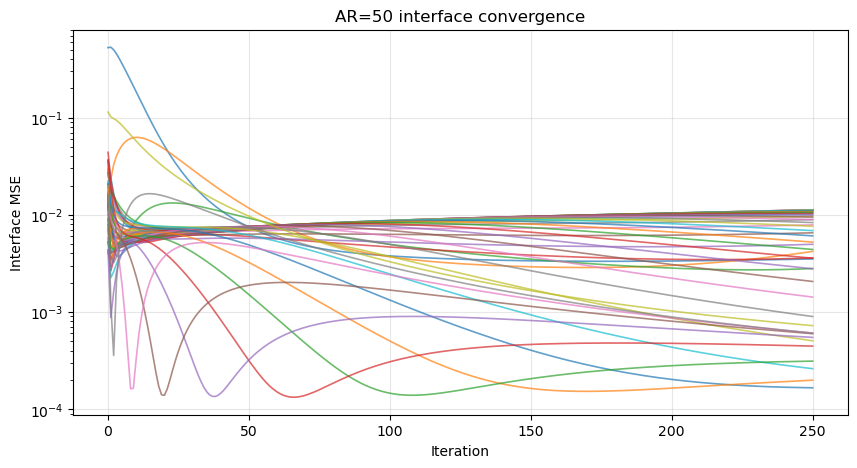

In [50]:
mse_history = test_result["interface_mse_history"]
plt.figure(figsize=(10, 5))
for k in range(mse_history.shape[1]):
    plt.plot(mse_history[:, k], alpha=0.7, linewidth=1.2)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Interface MSE")
plt.title("AR=50 interface convergence")
plt.grid(True, alpha=0.3)
plt.show()

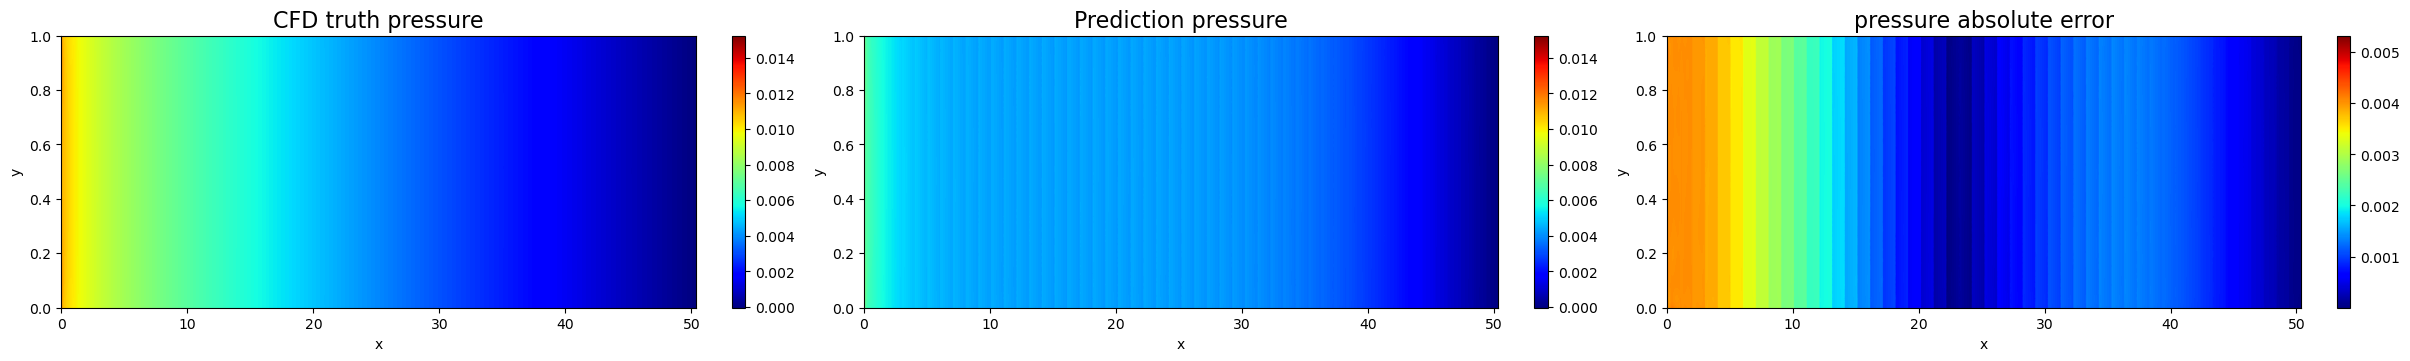

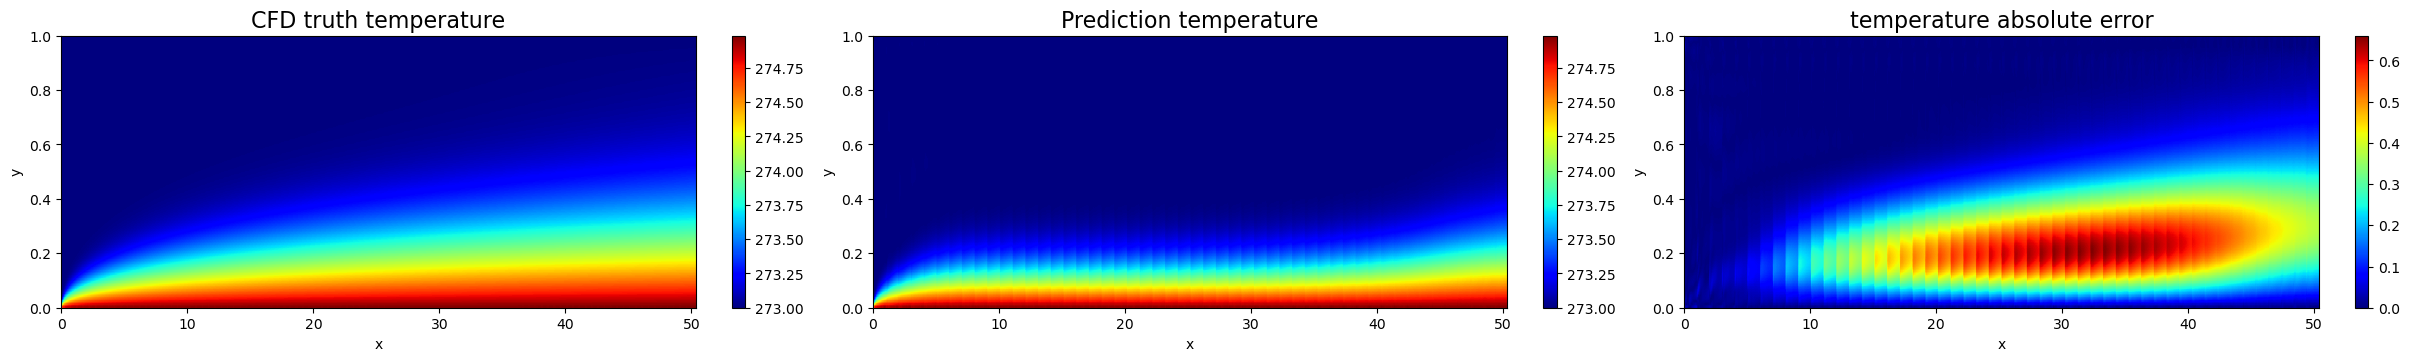

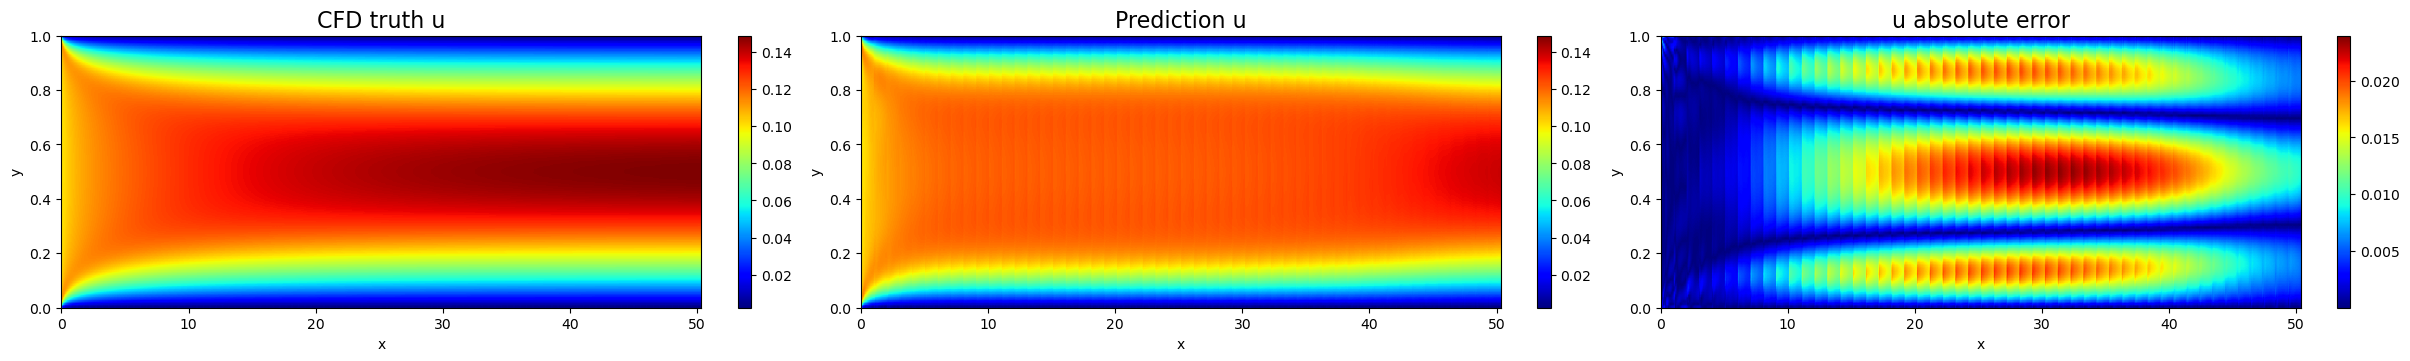

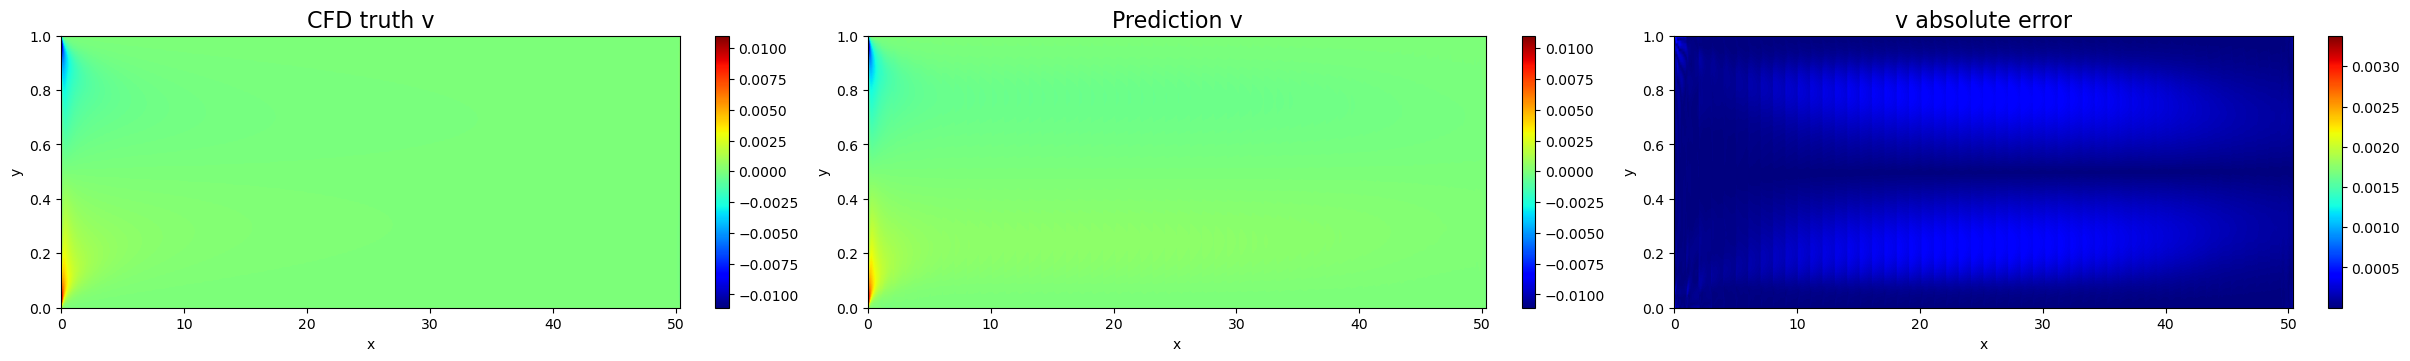

In [51]:
p_plot = make_plot_dict_from_iterative_result(
    result=test_result,
    data=test_data,
    sample_indices=sample_test_ids,
    nondimensionalize_xy=True,
)

for field_name in output_channel_names:
    field_idx = output_channel_names.index(field_name)

    plot_prediction_imshow_from_points(
        x=p_plot["x"],
        y=p_plot["y"],
        pred=p_plot["pred"],
        truth=p_plot["truth"],
        field_name=field_name,
        field_idx=field_idx,
        n_y_plot=100,
    )